<font size="3">**Tarea 3**</font>

<u> *Instrucciones* </u>

Los resultados de los ejericicios propuestos se deben entregar como un notebook por correo electronico a *juancaros@udec.cl* el dia 6/6 hasta las 21:00. Es importante considerar que el código debe poder ejecutarse en cualquier computadora con la data original del repositorio. Recordar la convencion para el nombre de archivo ademas de incluir en su documento titulos y encabezados por seccion. Utilizar la base de datos junaeb3.csv, el diccionario de datos es el siguiente:

- sexo: sexo del estudiante (1: mujer)
- edad: edad del estudiante (meses)
- imce: indice de masa corporal estandarizado (puntaje z)
- vive_padre: 1 si el padre vive en el hogar (2 indica que tiene mas de un padre)
- vive_madre: 2 si la madre vive en el hogar (2 indica que tiene mas de una madre)
- area: urbana=1, rural=0
- sk1: muestra afecto a padres (1: siempre - 5: nunca)
- sk2: muestra afecto a sus pares (1: siempre - 5: nunca)
- sk3: expresa sus sentimientos (1: siempre - 5: nunca)
- sk4: usa gestos para mostrar sentimientos (1: siempre - 5: nunca)
- sk5: juega con otros (1: siempre - 5: nunca)
- sk6: comparte sus cosas con otros (1: siempre - 5: nunca)
- sk7: es agresivo (1: siempre - 5: nunca)
- sk8: participa en juegos grupales (1: siempre - 5: nunca)
- sk9: hace preguntas a adultos (1: siempre - 5: nunca) 
- sk10: tiene interes por libros (1: siempre - 5: nunca) 
- sk11: tiene interes por su entorno (1: siempre - 5: nunca)
- sk12: juega a armar y desarmar cosas (1: siempre - 5: nunca) 
- sk13: tiene expresiones artisticas (1: siempre - 5: nunca) 
- act_fisica: frecuencia actividad fisica (1: nunca - 5: 5 o mas veces a la semana)
- educm: años de escolaridad de la madre
- educp: años de escolaridad del padre
- madre_work: si la madre trabaja (-1: labor domestica, 0: desempleada, 1: empleada)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import sklearn
import scipy 
from scipy.stats import nbinom
import seaborn as sns
from statsmodels.iolib.summary2 import summary_col
from factor_analyzer import FactorAnalyzer
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")
import semopy 

%matplotlib inline

Preguntas:

1. Cargue la base de datos y realice los ajustes necesarios para su uso (missing values, recodificar variables, etcetera). Identifique los tipos de datos que se encuentran en la base, realice estadisticas descriptivas sobre las variables importantes (Hint: Revisar la distribuciones, datos faltantes, outliers, etc.) y limpie las variables cuando sea necesario.

R: Se observa que la data tiene pocos datos nulos y de escalas similares, por lo que se decide eliminar los NaN únicamente. 

In [ ]:
df = pd.read_csv('../../data/junaeb3.csv')

In [3]:
df.dtypes

sexo            int64
edad            int64
imce          float64
vive_padre      int64
vive_madre      int64
sk1             int64
sk2             int64
sk3             int64
sk4             int64
sk5             int64
sk6             int64
sk7             int64
sk8             int64
sk9             int64
sk10            int64
sk11            int64
sk12            int64
sk13            int64
act_fisica    float64
area            int64
educm         float64
educp           int64
madre_work      int64
dtype: object

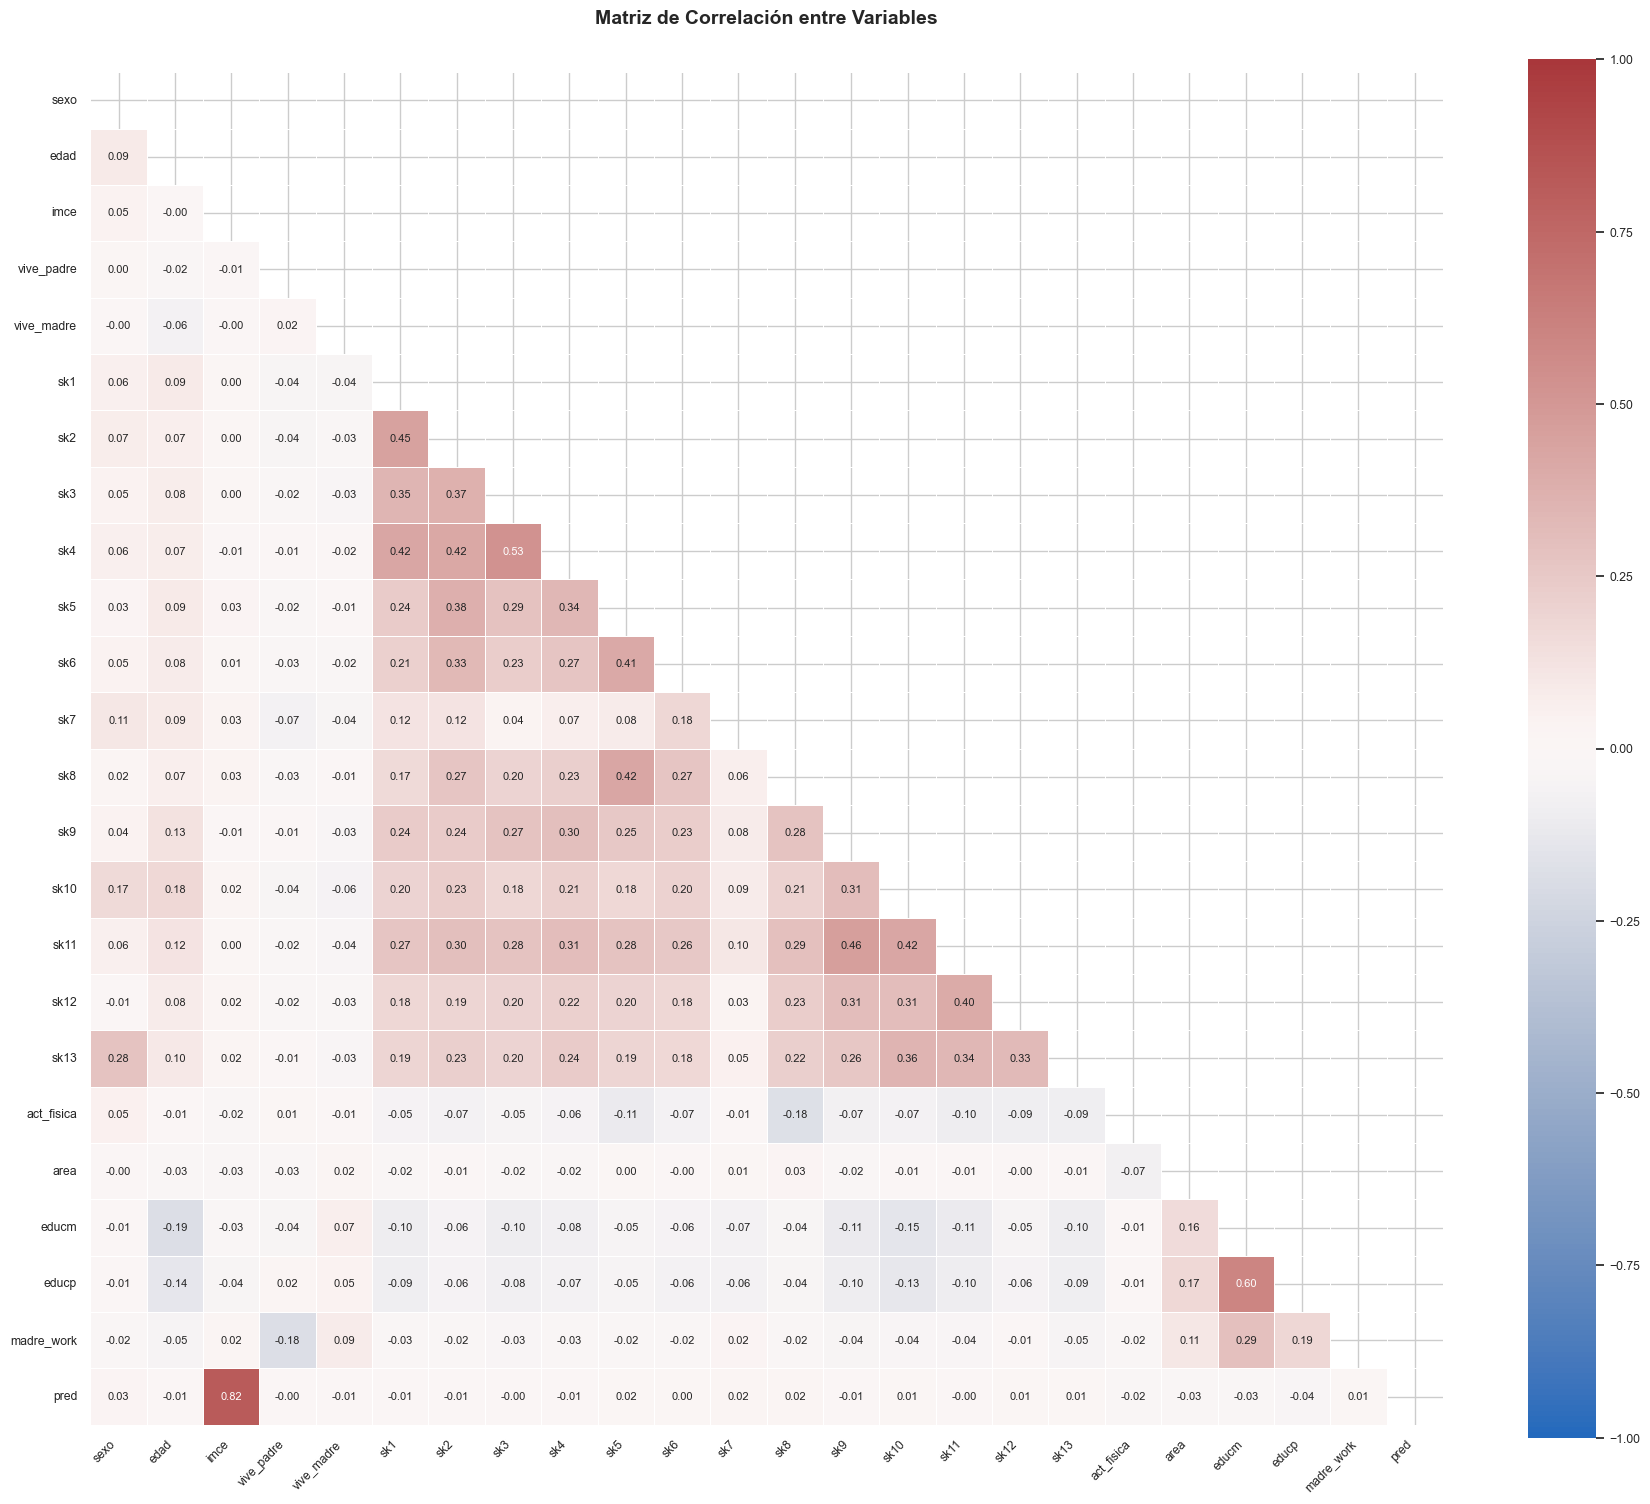

In [29]:
sns.set_theme(style="whitegrid", font_scale=0.8)

numeric_vars = df.select_dtypes(include=np.number).columns.tolist()

corr_matrix = df[numeric_vars].corr(method="pearson")


plt.figure(figsize=(18, 15))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

heatmap = sns.heatmap(
    corr_matrix,
    mask=mask,
    vmin=-1,
    vmax=1,
    center=0,
    cmap="vlag",
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8},
    linewidths=0.5,
    linecolor="white",
    square=True
)


plt.title("Matriz de Correlación entre Variables\n", fontsize=14, fontweight="bold", pad=20)
heatmap.set_xticklabels(heatmap.get_xticklabels(), rotation=45, ha="right")
heatmap.set_yticklabels(heatmap.get_yticklabels(), rotation=0)


plt.tight_layout()
plt.show()

2. A partir de las variables sk1-sk13 realice un EFA. En particular determine el numero optimo de factores y reporte las variables que se asocian a cada factor (usando los factor loadings). Tambien discuta si existen variables que no son informativas. (Hint: para realizar un EFA, todas las variables deben estar representatadas en el mismo sentido logico. Si una carateristica es negativa debe ser invertida en la escala, de tal forma que todas las variables representen aspectos positivos).

R: Se realizó un Análisis Factorial Exploratorio (EFA) sobre las variables sk1 a sk13, reteniendo 3 factores según el criterio de valores propios > 1.
Las cargas factoriales sugieren la siguiente estructura:

- Factor 1 (Exploración cognitiva): sk9, sk10, sk11, sk12, sk13
- Factor 2 (Expresión afectiva): sk1, sk2, sk3, sk4
- Factor 3 (Juego social): sk5, sk6, sk8

La variable sk7 (es agresivo) presenta muy baja comunalidad (0.029) y cargas débiles en los tres factores, por lo que se considera no informativa en esta estructura.

Variables como sk13 también tienen baja comunalidad (<0.3), por lo que su aporte es marginal y podrían ser revisadas en futuras versiones del modelo.

In [4]:
sk_cols = [f"sk{i}" for i in range(1, 14)]
data_sk = df[sk_cols].copy()

In [5]:
# Invertir sk7 (es agresivo)
data_sk["sk7"] = 6 - data_sk["sk7"]  # Ahora 5 = nunca agresivo → más positivo

In [6]:
data_sk.dropna(inplace=True)

Se observa que se deben realizar tres factores. 

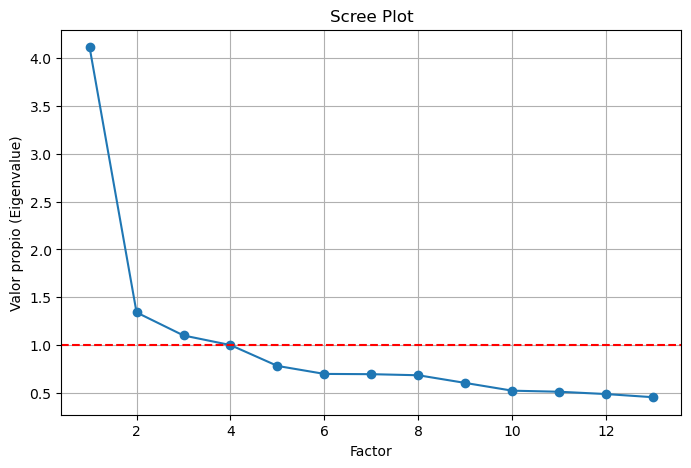

In [7]:
fa = FactorAnalyzer()
fa.fit(data_sk)

# Obtener valores propios
ev, v = fa.get_eigenvalues()

# Graficar scree plot
plt.figure(figsize=(8,5))
plt.plot(range(1, len(ev)+1), ev, marker='o')
plt.axhline(1, color='red', linestyle='--')
plt.title("Scree Plot")
plt.xlabel("Factor")
plt.ylabel("Valor propio (Eigenvalue)")
plt.grid()
plt.show()

In [8]:
fa = FactorAnalyzer(n_factors=3, rotation='varimax')
fa.fit(data_sk)

FactorAnalyzer(rotation='varimax', rotation_kwargs={})

In [9]:
loadings = pd.DataFrame(fa.loadings_, index=sk_cols)
print(loadings.round(3))

          0      1      2
sk1   0.184  0.549  0.156
sk2   0.177  0.517  0.350
sk3   0.183  0.597  0.168
sk4   0.199  0.686  0.201
sk5   0.121  0.220  0.725
sk6   0.173  0.211  0.481
sk7  -0.070 -0.075 -0.136
sk8   0.269  0.105  0.478
sk9   0.496  0.215  0.208
sk10  0.563  0.123  0.127
sk11  0.665  0.210  0.206
sk12  0.527  0.116  0.144
sk13  0.485  0.154  0.135


In [10]:
communalities = pd.DataFrame(fa.get_communalities(), index=sk_cols, columns=["Comunalidad"])
print(communalities.round(3))

      Comunalidad
sk1         0.360
sk2         0.422
sk3         0.418
sk4         0.551
sk5         0.589
sk6         0.306
sk7         0.029
sk8         0.312
sk9         0.336
sk10        0.349
sk11        0.529
sk12        0.312
sk13        0.277


In [11]:
scores = fa.transform(data_sk)


3. Con los resultados de la Pregunta 2, graficamente indique si existen diferencias significativas en la distribucion de los factores usando las siguientes variables para caracterizar: sexo, area, imce y act_fisica (Hint: usar scatterplot de factores en pares, y ocupar la opcion 'hue' para agregar variables de caracterizacion). Que puede concluir de los resultados?

R: En todos los casos, los gráficos mostraron una distribución homogénea y solapada de los puntos, sin evidencia visual clara de agrupamiento o separación entre los distintos grupos. Es decir, no se observaron patrones estructurados en el espacio de los factores que permitan diferenciar a los estudiantes según las variables de caracterización analizadas.

Los factores latentes definidos (como expresión emocional, juego social o exploración cognitiva) no muestran diferencias marcadas entre estudiantes según sexo, nivel de actividad física, entorno (urbano/rural) ni estado nutricional (imce categorizado).

Esto sugiere que, dentro de esta muestra, las dimensiones socioemocionales exploradas no están fuertemente determinadas por estas características contextuales.

In [ ]:
df_matched = df.loc[data_sk.index].reset_index(drop=True)
factor_scores = pd.DataFrame(fa.transform(data_sk), columns=['Factor1', 'Factor2', 'Factor3'])
factor_scores = pd.concat([factor_scores, df_matched[['sexo', 'area', 'imce', 'act_fisica']].reset_index(drop=True)], axis=1)

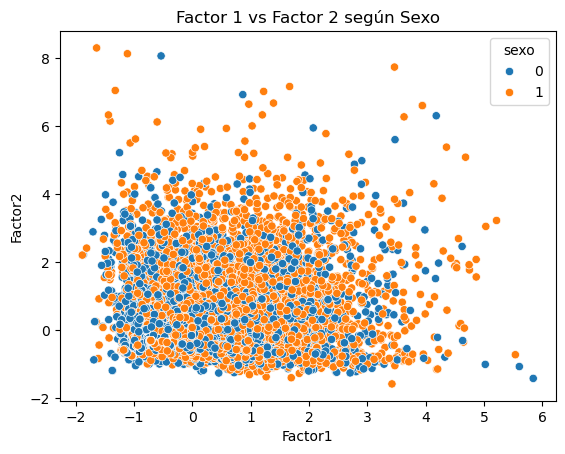

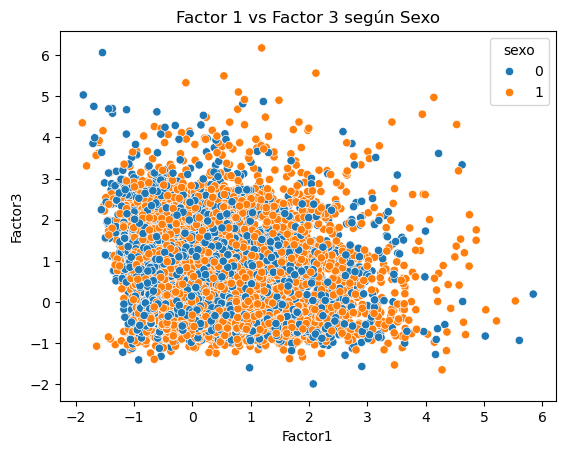

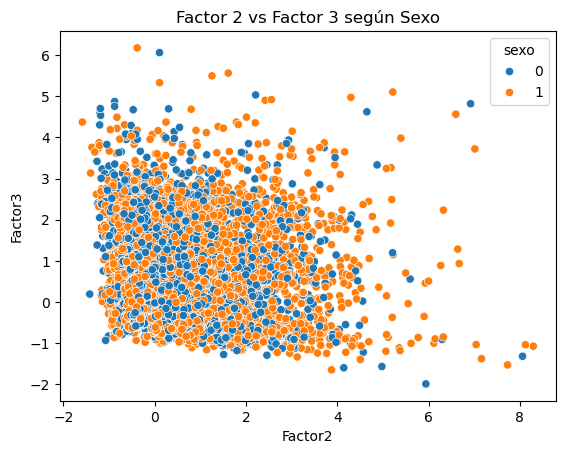

In [ ]:
# Sexo (1 = mujer)
sns.scatterplot(data=factor_scores, x='Factor1', y='Factor2', hue='sexo')
plt.title('Factor 1 vs Factor 2 según Sexo')
plt.show()

sns.scatterplot(data=factor_scores, x='Factor1', y='Factor3', hue='sexo')
plt.title('Factor 1 vs Factor 3 según Sexo')
plt.show()

sns.scatterplot(data=factor_scores, x='Factor2', y='Factor3', hue='sexo')
plt.title('Factor 2 vs Factor 3 según Sexo')
plt.show()

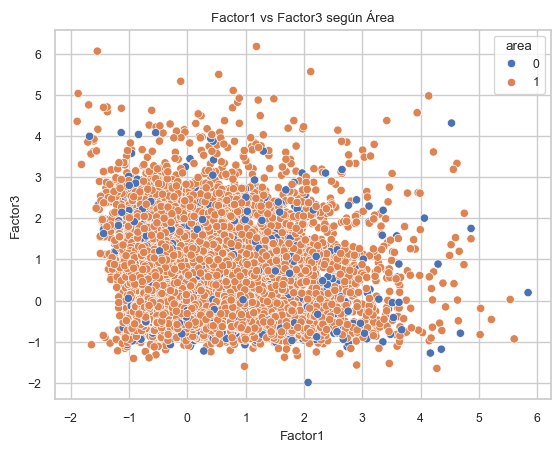

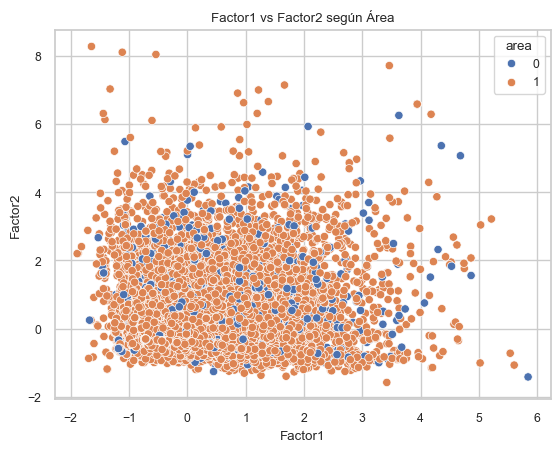

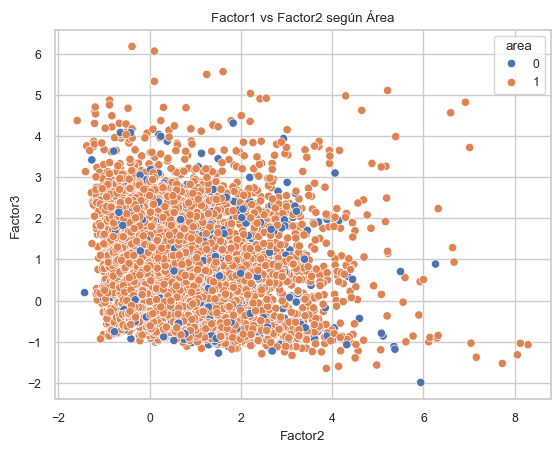

In [30]:
# Área (1 = urbana)
sns.scatterplot(data=factor_scores, x='Factor1', y='Factor3', hue='area')
plt.title('Factor1 vs Factor3 según Área')
plt.show()

sns.scatterplot(data=factor_scores, x='Factor1', y='Factor2', hue='area')
plt.title('Factor1 vs Factor2 según Área')
plt.show()

sns.scatterplot(data=factor_scores, x='Factor2', y='Factor3', hue='area')
plt.title('Factor1 vs Factor2 según Área')
plt.show()

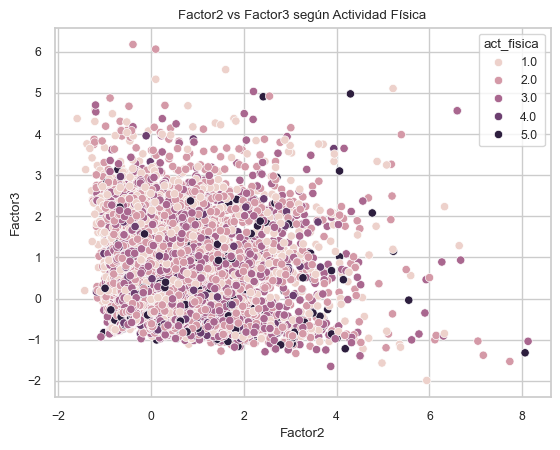

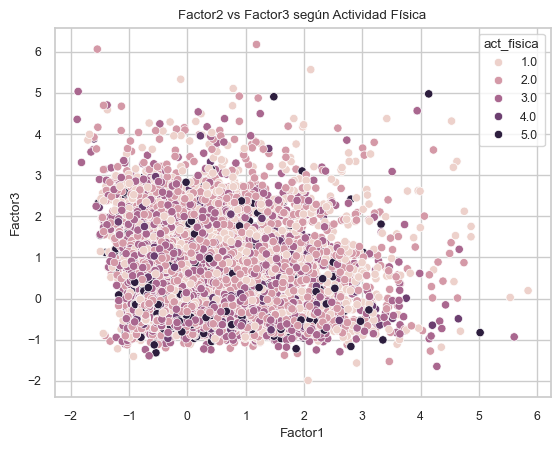

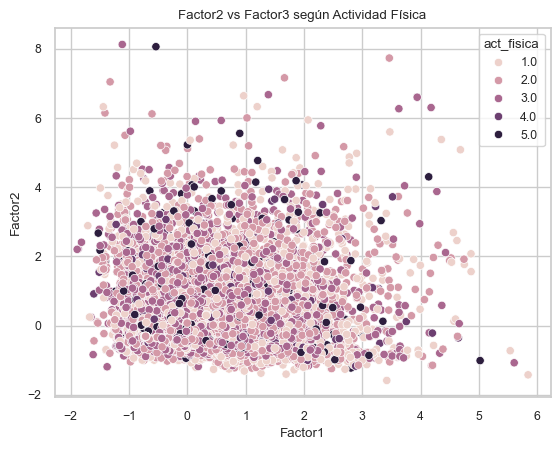

In [31]:
# Actividad física
sns.scatterplot(data=factor_scores, x='Factor2', y='Factor3', hue='act_fisica')
plt.title('Factor2 vs Factor3 según Actividad Física')
plt.show()

sns.scatterplot(data=factor_scores, x='Factor1', y='Factor3', hue='act_fisica')
plt.title('Factor2 vs Factor3 según Actividad Física')
plt.show()

sns.scatterplot(data=factor_scores, x='Factor1', y='Factor2', hue='act_fisica')
plt.title('Factor2 vs Factor3 según Actividad Física')
plt.show()

Categorizar IMCE:

In [15]:
# Asignar categorías de IMC según puntaje z
def categorizar_imce(z):
    if z < -1:
        return 'Bajo peso'
    elif z <= 1:
        return 'Normal'
    else:
        return 'Sobrepeso/Obesidad'

# Crear columna nueva con las categorías
factor_scores['imce_cat'] = factor_scores['imce'].apply(categorizar_imce)


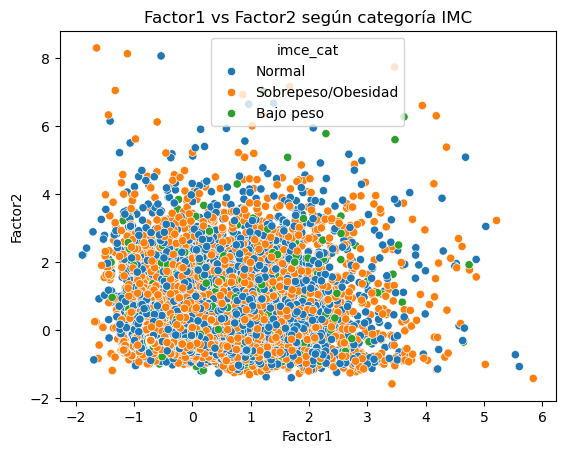

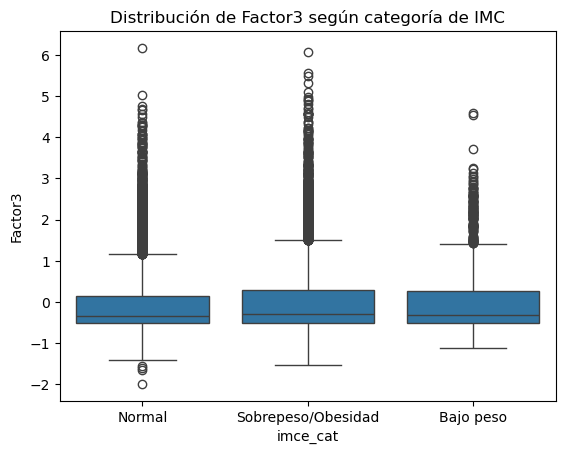

In [16]:
# Scatterplot: Factor1 vs Factor2 coloreado por categoría de IMC
sns.scatterplot(data=factor_scores, x='Factor1', y='Factor2', hue='imce_cat')
plt.title("Factor1 vs Factor2 según categoría IMC")
plt.show()

# Boxplot: Distribución de Factor3 por categoría de IMC
sns.boxplot(data=factor_scores, x='imce_cat', y='Factor3')
plt.title("Distribución de Factor3 según categoría de IMC")
plt.show()


4. Con los resultados obtenidos en la Pregunta 2, proponga un CFA donde cada variable solo se asocia con un factor. Entregue un nombre a cada factor que representa el concepto comun entre las variables incluidas. Reporte la importancia de cada medida (variable) a cada factor e indique la correlacion entre factores (loadings). 

R: El modelo CFA fue ajustado correctamente usando el método de máxima verosimilitud ponderada (MLW). El optimizador convergió exitosamente en 42 iteraciones.

El ajuste global fue:

- TLI = 0.936 (mayor al umbral ideal de 0.90)
- RMSEA = 0.052 (ligeramente por encima de 0.05, pero igual aceptable)

Las cargas estandarizadas (Est. Std) obtenidas en el modelo CFA indican que todas las variables incluidas son buenas o aceptables medidas de sus factores respectivos. Las variables sk11 (0.736), sk4 (0.716) y sk5 (0.718) mostraron las cargas más altas, lo que sugiere que son fuertes indicadores latentes de Exploración, Expresión emocional y Juego social, respectivamente. Ninguna variable presentó una carga menor a 0.5, lo que valida su inclusión en el modelo.

Además, se observaron correlaciones positivas y moderadas entre los factores latentes:

- Exploración y Expresión: 0.604
- Exploración y Juego: 0.593
- Expresión y Juego: 0.657

Estas correlaciones son consistentes con la idea de que los distintos dominios socioemocionales del desarrollo infantil están relacionados entre sí, pero miden aspectos diferenciados.

In [17]:
from semopy import Model, Optimizer
import pandas as pd

# Definir modelo CFA con 3 factores
model_desc = """
Exploracion =~ sk9 + sk10 + sk11 + sk12 + sk13
Expresion =~ sk1 + sk2 + sk3 + sk4
Juego =~ sk5 + sk6 + sk8
"""

# Usamos solo las variables incluidas
sk_vars = ['sk1','sk2','sk3','sk4','sk5','sk6','sk8','sk9','sk10','sk11','sk12','sk13']
df_cfa = df[sk_vars].dropna()

# Crear el modelo
mod = Model(model_desc)

# Cargar datos al modelo
mod.load_dataset(df_cfa)

# Optimizar (ajustar)
mod.fit()


SolverResult(fun=0.14172809443309298, success=True, n_it=42, x=array([1.33471289, 1.23280677, 1.09194965, 1.26141689, 1.7931574 ,
       1.60342231, 1.77796013, 1.02663242, 1.15530971, 0.15991308,
       0.05512946, 0.05675658, 0.06271065, 0.16531014, 0.09646983,
       0.10011786, 0.60083687, 0.20422901, 0.44826838, 0.71567497,
       0.24529335, 0.20138668, 0.16014306, 0.15387964, 0.37594032,
       0.47618537, 0.28354875]), message='Optimization terminated successfully', name_method='SLSQP', name_obj='MLW')

In [18]:
# Para ver los coeficientes (loadings)
mod.inspect()

# Para ver los indicadores de ajuste (TLI, RMSEA, etc.)
from semopy import calc_stats
stats = calc_stats(mod)
print("TLI:", stats["TLI"])
print("RMSEA:", stats["RMSEA"])


TLI: Value    0.935692
Name: TLI, dtype: float64
RMSEA: Value    0.052411
Name: RMSEA, dtype: float64


In [19]:
# Ver los parámetros estimados (incluye las cargas y varianzas)
loadings = mod.inspect(std_est=True)
print(loadings)

           lval  op         rval  Estimate  Est. Std  Std. Err     z-value  \
0           sk9   ~  Exploracion  1.000000  0.600501         -           -   
1          sk10   ~  Exploracion  1.334713  0.567130  0.017645   75.641962   
2          sk11   ~  Exploracion  1.232807  0.737146  0.013993   88.102986   
3          sk12   ~  Exploracion  1.091950  0.546278  0.014832   73.622089   
4          sk13   ~  Exploracion  1.261417  0.512138  0.017981   70.151539   
5           sk1   ~    Expresion  1.000000  0.595909         -           -   
6           sk2   ~    Expresion  1.793157  0.647690  0.021586   83.072223   
7           sk3   ~    Expresion  1.603422  0.642710  0.019395   82.673817   
8           sk4   ~    Expresion  1.777960  0.721890  0.020174   88.132298   
9           sk5   ~        Juego  1.000000  0.719657         -           -   
10          sk6   ~        Juego  1.026632  0.562749  0.013824   74.266085   
11          sk8   ~        Juego  1.155310  0.562710  0.015557  

5. Estime un modelo de clases latentes usando imce via StepMix. Determine el numero optimo de clases (clusters) y muestre las diferencias entre clusters graficamente. Que se puede concluir de los resultados?

R: Se estimó un modelo de clases latentes usando la variable imce, considerando entre 2 y 9 clases. El número óptimo de clases fue K = 4, determinado por el criterio BIC.

Las clases resultantes muestran diferencias marcadas en sus medias de imce:

- Clase 1 (1%): IMCE extremadamente bajo → posible bajo peso severo
- Clase 2 (52%): IMCE levemente alto → estudiantes con peso normal o sobrepeso leve
- Clase 3 (17%): IMCE muy alto → posible obesidad
- Clase 0 (30%): IMCE cercano a 0 → peso saludable promedio

La distribución fue visualizada mediante un boxplot, donde se observa la separación entre clases.
El modelo mostró un ajuste adecuado (log-likelihood = −53706, entropy escalar = 0.466) aunque con algo de solapamiento entre clases. 

Este resultado sugiere que, aunque imce es una variable continua, puede segmentarse en categorías nutricionales latentes significativas dentro de la población escolar analizada. Esta segmentación puede resultar útil para diseñar intervenciones de salud diferenciadas por grupo, mejorar políticas nutricionales escolares, entre otras posibilidades.

Sobre los porcentajes, se observa que solo 1 de cada 3 estudiantes cae dentro de un rango 'saludable', mientras que aquellos con sobrepeso o riesgo nutricional representan más de dos tercios de los estudiantes, particularmente con una mayor cantidad de estudiantes con sobrepeso, lo cual representa un desafío importante en salud pública escolar.



In [32]:
from stepmix.stepmix import StepMix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

df1 = df[['imce']].dropna()

Fitting StepMix...


Initializations (n_init) : 100%|██████████████████████| 1/1 [00:01<00:00,  1.01s/it, max_LL=-5.42e+4, max_avg_LL=-1.75]


Fitting StepMix...


Initializations (n_init) : 100%|██████████████████████| 1/1 [00:02<00:00,  2.64s/it, max_LL=-5.37e+4, max_avg_LL=-1.73]


Fitting StepMix...


...

Initializations (n_init) : 100%|██████████████████████| 1/1 [00:11<00:00, 11.53s/it, max_LL=-5.37e+4, max_avg_LL=-1.73]


Fitting StepMix...


Initializations (n_init) : 100%|██████████████████████| 1/1 [00:12<00:00, 12.66s/it, max_LL=-5.37e+4, max_avg_LL=-1.73]


Fitting StepMix...


Initializations (n_init) : 100%|██████████████████████| 1/1 [00:14<00:00, 14.19s/it, max_LL=-5.37e+4, max_avg_LL=-1.73]


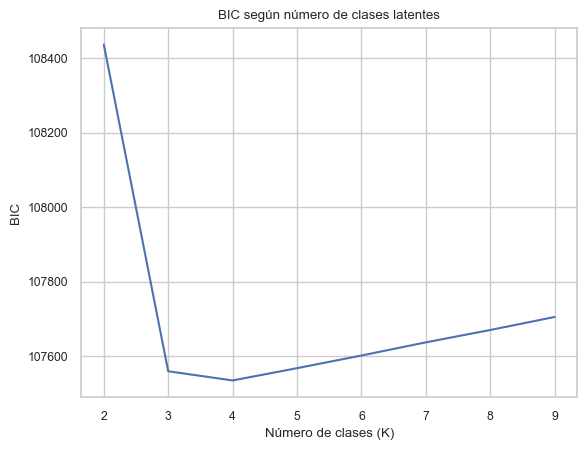

In [33]:
K = range(2, 10)
fits = []
BIC = []

for k in K:
    model = StepMix(n_components=k, measurement='gaussian', verbose=0, random_state=123).fit(df1)
    fits.append(model)
    BIC.append(model.sabic(df1))

sns.lineplot(x=K, y=BIC)
plt.title("BIC según número de clases latentes")
plt.xlabel("Número de clases (K)")
plt.ylabel("BIC")
plt.show()

In [ ]:
model = StepMix(n_components=4, measurement='gaussian', verbose=1, random_state=123)
model.fit(df1)
df1['pred'] = model.predict(df1)

Fitting StepMix...


Initializations (n_init) : 100%|██████████████████████| 1/1 [00:06<00:00,  6.44s/it, max_LL=-5.37e+4, max_avg_LL=-1.73]

MODEL REPORT
    Measurement model parameters
          model_name     gaussian_unit                        
          class_no                   0       1       2       3
          param variable                                      
          means imce             0.075 -2.6526  1.0992  2.6792
    Class weights
        Class 1 : 0.30
        Class 2 : 0.01
        Class 3 : 0.52
        Class 4 : 0.17
    Fit for 4 latent classes
    Estimation method             : 1-step
    Number of observations        : 31055
    Number of latent classes      : 4
    Number of estimated parameters: 7
    Log-likelihood (LL)           : -53706.0594
    -2LL                          : 107412.1188
    Average LL                    : -1.7294
    AIC                           : 107426.12
    BIC                           : 107484.52
    CAIC                          : 107491.52
    Sample-Size Adjusted BIC      : 107534.68
    Entropy                       : 23000.1182
    Scaled Relative Entropy    

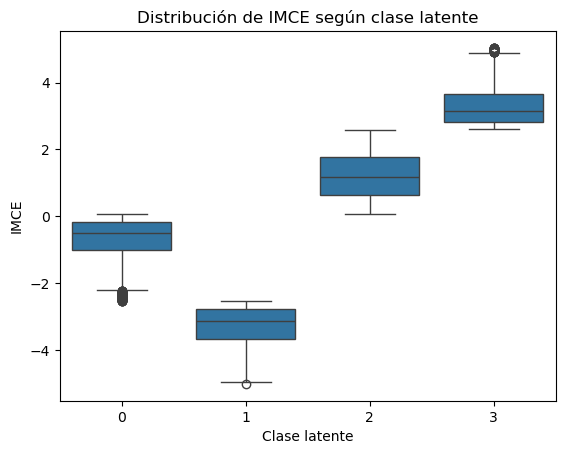

In [23]:
sns.boxplot(data=df1, x='pred', y='imce')
plt.title("Distribución de IMCE según clase latente")
plt.xlabel("Clase latente")
plt.ylabel("IMCE")
plt.show()

6. Implemente un SEM completo usando la estructura propuesta en la Pregunta 4. En particular, estime un modelo donde los factores latentes explican el imce, junto con otras variables que existen en la base de datos. Ademas utilice otras variables relevantes de la base de datos para su modelo. Las variables a incluir en el modelo final deben tener sustento teorico y el modelo final debe optimizar el ajuste a los datos, en base a los criterios vistos en clase (TLI, CLI, RMSEA). Que puede concluir en base a sus resultados?

R: El modelo mostró buen ajuste global (TLI = 0.876, CFI = 0.891, RMSEA = 0.044). Este modelo SEM permite integrar factores psicosociales (como expresión emocional, juego social) con condiciones familiares y contextuales (educación de la madre, área, trabajo materno, etc.) para explicar las diferencias en el estado nutricional de los niños, representado por el IMCE.

- El factor Expresión emocional tiene un efecto protector: niños que expresan más sus emociones tienden a tener menor IMCE, lo cual podría vincularse a mayor autorregulación emocional y hábitos más saludables.
- El factor Juego social tiene efecto opuesto: más juego se asocia con mayor IMCE, lo que podría interpretarse como: participación en juegos sedentarios, mayor integración social, pero con hábitos menos saludables, o una variable que co-varía con otras (por ejemplo, juntarse a comer con amigos).
- La actividad física muestra su efecto esperado: protege contra el sobrepeso.
- Condiciones sociales como menor escolaridad materna, residencia rural, madres que trabajan fuera del hogar se asocian con mayor IMCE, probablemente debido a menores niveles de supervisión, educación alimentaria o acceso a alimentos saludables.

In [ ]:
from semopy import Model, calc_stats
import pandas as pd

model_desc = """
# Measurement model (confirmatory)
Exploracion =~ sk9 + sk10 + sk11 + sk12 + sk13
Expresion =~ sk1 + sk2 + sk3 + sk4
Juego =~ sk5 + sk6 + sk8

# Structural model (imce explicado por factores + covariables)
imce ~ Exploracion + Expresion + Juego + act_fisica + sexo + educm + area + vive_padre + vive_madre + madre_work
"""

vars_used = [
    'sk1', 'sk2', 'sk3', 'sk4',
    'sk5', 'sk6', 'sk8',
    'sk9', 'sk10', 'sk11', 'sk12', 'sk13',
    'imce', 'act_fisica', 'sexo', 'educm', 'area',
    'vive_padre', 'vive_madre', 'madre_work'
]

df_sem = df[vars_used].dropna()

mod = Model(model_desc)
mod.load_dataset(df_sem)
mod.fit()

stats = calc_stats(mod)
print("=== Ajuste del modelo SEM ===")
print("TLI:", round(stats["TLI"], 3))
print("CFI:", round(stats["CFI"], 3))
print("RMSEA:", round(stats["RMSEA"], 3))

results = mod.inspect(std_est=True)
results[['lval', 'op', 'rval', 'Estimate', 'Est. Std', 'p-value']]


=== Ajuste del modelo SEM ===
TLI: Value    0.876
Name: TLI, dtype: float64
CFI: Value    0.891
Name: CFI, dtype: float64
RMSEA: Value    0.044
Name: RMSEA, dtype: float64


,lval,op,rval,Estimate,Est. Std,p-value
0,sk9,~,Exploracion,1.000000,0.594633,-
1,sk10,~,Exploracion,1.347336,0.562433,0.0
2,sk11,~,Exploracion,1.247418,0.736009,0.0
3,sk12,~,Exploracion,1.097411,0.540905,0.0
4,sk13,~,Exploracion,1.272762,0.506227,0.0
5,sk1,~,Expresion,1.000000,0.582358,-
6,sk2,~,Expresion,1.878795,0.644765,0.0
7,sk3,~,Expresion,1.646529,0.631629,0.0
8,sk4,~,Expresion,1.847580,0.716010,0.0
9,sk5,~,Juego,1.000000,0.717865,-


7. Repita el analisis de la Pregunta 6 usando para cada submuestra generada a partir de las clases latentes obtenida en la pregunta 5. Reporte diferencias entre los parametros entre los distintos grupos (si existieran). Hay alguna ganancia de estimar el modelo por grupos versus el modelo general?  

- Repetir pregunta 6 pero por grupos. Aplicar clases latentes al IMC. Ocupar librería StepMix. Correr el modelo estructural pero por cada grupo separado para encontrar diferencias entre grupos significativas. Al segmentar la data se pierde poder estadístico. 

R: Los modelos mostraron en general buen ajuste global (TLI ≈ 0.87, RMSEA < 0.05), excepto en la Clase 1 (solo 1% de la muestra), donde la estimación fue menos estable.

El efecto de los factores latentes sobre el IMCE cambia entre clases:

- En la Clase 3 (obesidad), el juego social muestra un efecto positivo y significativo sobre el IMCE (Est. Std = 0.099, p = 0.003), indicando que en este grupo, mayor participación social podría estar asociada a conductas sedentarias o hábitos poco saludables.
- En la Clase 2 (sobrepeso leve/moderado), el juego también tiene efecto positivo, pero menor.
- En la Clase 0 (IMCE normal) y la Clase 1 (bajo peso), ninguno de los factores latentes es significativo, lo que sugiere que otras variables predominan.

En cuanto a las variables observadas:

- La actividad física es positiva en Clase 1 (bajo peso) y negativa en Clase 2 (sobrepeso), lo que calza con una interpretación coherente desde la salud pública: moverse más ayuda en el sobrepeso, pero en niños con bajo peso puede incluso incrementar el gasto calórico sin beneficio.
- El sexo tiene efecto positivo en clases altas de IMCE (Clase 2 y 3), sugiriendo que niñas en estas clases tienen mayor IMCE que niños.
- La educación materna protege especialmente en las clases con IMCE más alto.
- El efecto del trabajo de la madre solo fue significativo en Clase 2, asociado a mayor IMCE.

La segmentación por clases latentes permite observar dinámicas específicas según el estado nutricional del niño que no eran visibles en el modelo general. En particular, el efecto del juego social y de la actividad física cambia de forma relevante entre grupos, lo que respalda la utilidad de esta segmentación. Sin embargo, esta estrategia reduce el poder estadístico (especialmente en clases pequeñas), por lo que se debe interpretar con precaución.

In [38]:
df1 = df[['imce']].dropna()
model = StepMix(n_components=4, measurement='gaussian', random_state=123)
model.fit(df1)
df1['pred'] = model.predict(df1)

Fitting StepMix...


Initializations (n_init) : 100%|██████████████████████| 1/1 [00:06<00:00,  6.73s/it, max_LL=-5.37e+4, max_avg_LL=-1.73]


In [ ]:
df['pred'] = df1['pred']

In [ ]:
from semopy import Model, calc_stats

model_desc = """
Exploracion =~ sk9 + sk10 + sk11 + sk12 + sk13
Expresion =~ sk1 + sk2 + sk3 + sk4
Juego =~ sk5 + sk6 + sk8

imce ~ Exploracion + Expresion + Juego + act_fisica + sexo + educm + area + vive_padre + vive_madre + madre_work
"""
resultados = []
for clase in range(4):
    print(f"=== CLASE LATENTE {clase} ===")
    subdf = df[df['pred'] == clase]
    vars_used = ['sk1','sk2','sk3','sk4','sk5','sk6','sk8','sk9','sk10','sk11','sk12','sk13',
                 'imce','act_fisica','sexo','educm','area','vive_padre', 'vive_madre', 'madre_work']
    subdf = subdf[vars_used].dropna()

    if len(subdf) < 200:
        print(f"Clase {clase} tiene pocos datos ({len(subdf)}). Puede afectar la estabilidad.")
    
    mod = Model(model_desc)
    mod.load_dataset(subdf)
    mod.fit()
    
    stats = calc_stats(mod)
    print(f"TLI: {round(stats['TLI'], 3)}, CFI: {round(stats['CFI'], 3)}, RMSEA: {round(stats['RMSEA'], 3)}")
    
    coef = mod.inspect(std_est=True)
    resultados.append((clase, coef))


=== CLASE LATENTE 0 ===
TLI: Value    0.879
Name: TLI, dtype: float64, CFI: Value    0.895
Name: CFI, dtype: float64, RMSEA: Value    0.044
Name: RMSEA, dtype: float64
=== CLASE LATENTE 1 ===
Clase 1 tiene pocos datos (199). Puede afectar la estabilidad.
TLI: Value    0.826
Name: TLI, dtype: float64, CFI: Value    0.848
Name: CFI, dtype: float64, RMSEA: Value    0.054
Name: RMSEA, dtype: float64
=== CLASE LATENTE 2 ===
TLI: Value    0.874
Name: TLI, dtype: float64, CFI: Value    0.89
Name: CFI, dtype: float64, RMSEA: Value    0.044
Name: RMSEA, dtype: float64
=== CLASE LATENTE 3 ===
TLI: Value    0.871
Name: TLI, dtype: float64, CFI: Value    0.887
Name: CFI, dtype: float64, RMSEA: Value    0.046
Name: RMSEA, dtype: float64


In [42]:
for clase, coef in resultados:
    print(f"\n=== PARÁMETROS ESTIMADOS - CLASE {clase} ===")
    display(coef[['lval', 'op', 'rval', 'Estimate', 'Est. Std', 'p-value']])


=== PARÁMETROS ESTIMADOS - CLASE 0 ===


,lval,op,rval,Estimate,Est. Std,p-value
0,sk9,~,Exploracion,1.000000,0.602693,-
1,sk10,~,Exploracion,1.255929,0.550529,0.0
2,sk11,~,Exploracion,1.226433,0.737580,0.0
3,sk12,~,Exploracion,1.037848,0.540666,0.0
4,sk13,~,Exploracion,1.192213,0.499876,0.0
5,sk1,~,Expresion,1.000000,0.567825,-
6,sk2,~,Expresion,1.806840,0.624567,0.0
7,sk3,~,Expresion,1.670613,0.657080,0.0
8,sk4,~,Expresion,1.925060,0.739488,0.0
9,sk5,~,Juego,1.000000,0.718798,-



=== PARÁMETROS ESTIMADOS - CLASE 1 ===


,lval,op,rval,Estimate,Est. Std,p-value
0,sk9,~,Exploracion,1.000000,0.665440,-
1,sk10,~,Exploracion,1.101011,0.521666,0.0
2,sk11,~,Exploracion,1.136907,0.776648,0.0
3,sk12,~,Exploracion,0.886639,0.570227,0.0
4,sk13,~,Exploracion,1.056241,0.472210,0.0
5,sk1,~,Expresion,1.000000,0.391341,-
6,sk2,~,Expresion,3.419815,0.734496,0.000001
7,sk3,~,Expresion,2.941701,0.658268,0.000002
8,sk4,~,Expresion,2.927340,0.740854,0.000001
9,sk5,~,Juego,1.000000,0.790535,-



=== PARÁMETROS ESTIMADOS - CLASE 2 ===


,lval,op,rval,Estimate,Est. Std,p-value
0,sk9,~,Exploracion,1.000000,0.587184,-
1,sk10,~,Exploracion,1.377928,0.564922,0.0
2,sk11,~,Exploracion,1.255557,0.735368,0.0
3,sk12,~,Exploracion,1.111667,0.536444,0.0
4,sk13,~,Exploracion,1.284702,0.500830,0.0
5,sk1,~,Expresion,1.000000,0.583247,-
6,sk2,~,Expresion,1.909319,0.648000,0.0
7,sk3,~,Expresion,1.674506,0.628059,0.0
8,sk4,~,Expresion,1.851548,0.708005,0.0
9,sk5,~,Juego,1.000000,0.714585,-



=== PARÁMETROS ESTIMADOS - CLASE 3 ===


,lval,op,rval,Estimate,Est. Std,p-value
0,sk9,~,Exploracion,1.000000,0.611419,-
1,sk10,~,Exploracion,1.379302,0.570930,0.0
2,sk11,~,Exploracion,1.254540,0.734272,0.0
3,sk12,~,Exploracion,1.150780,0.559945,0.0
4,sk13,~,Exploracion,1.370595,0.542240,0.0
5,sk1,~,Expresion,1.000000,0.613549,-
6,sk2,~,Expresion,1.829576,0.662443,0.0
7,sk3,~,Expresion,1.461720,0.605236,0.0
8,sk4,~,Expresion,1.670776,0.709688,0.0
9,sk5,~,Juego,1.000000,0.729264,-
